In [1]:
import os

chkpt_root = 'checkpoints/fa1t_38_run_2'
data_files = 'data/tfrecords/val/*'
tces_file = 'data/tces-v14-val.csv'

nruns = 10

def load_ensemble(chkpt_root, nruns):
    checkpts = []
    for i in range(nruns):
        parent = os.path.join(chkpt_root, str(i + 1))
        if not os.path.exists(parent):
            break
        all_dirs = os.listdir(parent)
        if not all_dirs:
            break
        d, = all_dirs
        checkpts.append(os.path.join(parent, d))
    return checkpts

paths = load_ensemble(chkpt_root, nruns)
paths

['checkpoints/fa1t_38_run_2\\1\\AstroCNNModel_final_alpha_1_tuned_20260420_141526',
 'checkpoints/fa1t_38_run_2\\2\\AstroCNNModel_final_alpha_1_tuned_20260420_142412',
 'checkpoints/fa1t_38_run_2\\3\\AstroCNNModel_final_alpha_1_tuned_20260420_143249',
 'checkpoints/fa1t_38_run_2\\4\\AstroCNNModel_final_alpha_1_tuned_20260420_144117',
 'checkpoints/fa1t_38_run_2\\5\\AstroCNNModel_final_alpha_1_tuned_20260420_144958',
 'checkpoints/fa1t_38_run_2\\6\\AstroCNNModel_final_alpha_1_tuned_20260420_145836',
 'checkpoints/fa1t_38_run_2\\7\\AstroCNNModel_final_alpha_1_tuned_20260420_150716',
 'checkpoints/fa1t_38_run_2\\8\\AstroCNNModel_final_alpha_1_tuned_20260420_151546',
 'checkpoints/fa1t_38_run_2\\9\\AstroCNNModel_final_alpha_1_tuned_20260420_152421',
 'checkpoints/fa1t_38_run_2\\10\\AstroCNNModel_final_alpha_1_tuned_20260420_153324']

In [2]:
import getpass
import os
from astronet import predict
import tensorflow as tf


def run_predictions(path):
    predict.FLAGS = predict.parser.parse_args([
      '--model_dir', path,
      '--data_files', data_files,
      '--output_file', '',
    ])

    return predict.predict()


paths = load_ensemble(chkpt_root, nruns)
ensemble_preds = []
config = None
for i, path in enumerate(paths):
    print(f'Running model {i + 1}')
    preds, config = run_predictions(path)
    ensemble_preds.append(preds.set_index('astro_id'))
    print()

Running model 1
2491 records
Running model 2
2491 records
Running model 3
2491 records
Running model 4
2491 records
Running model 5
2491 records
Running model 6
2491 records
Running model 7
2491 records
Running model 8
2491 records
Running model 9
2491 records
Running model 10
2491 records


In [3]:
labels = ['disp_e', 'disp_n', 'disp_j', 'disp_s', 'disp_b']

col_e = labels.index('disp_e')
thresh = 0.215

In [4]:
import numpy as np
import pandas as pd

agg_preds = {}

for preds in ensemble_preds:
    for ex_id in preds.index:
        if ex_id not in agg_preds:
            agg_preds[ex_id] = []

        row = preds[preds.index == ex_id]
        pred_v = row.values[0]
        if len(row.values) > 1:
            print(f'Warning: duplicate predictions for {ex_id}')
        if pred_v[col_e] >= thresh:
            agg_preds[ex_id].append('disp_e')
        else:
            masked_v = [v if i != col_e else 0 for i, v in enumerate(pred_v)]
            agg_preds[ex_id].append(preds.columns[np.argmax(masked_v)])

In [5]:
final_preds = []
for ex_id in list(agg_preds.keys()):
    counts = {l: 0 for l in labels}
    for e in agg_preds[ex_id]:
        counts[e] += 1
    maxcount = max(counts.values())
    counts.update({
        'astro_id': ex_id,
        'maxcount': maxcount,
    })
    final_preds.append(counts)
    
final_preds = pd.DataFrame(final_preds).set_index('astro_id')

In [6]:
tce_table = pd.read_csv(tces_file, header=0, low_memory=False)
tce_table['astro_id'] = tce_table['Astro ID']
tce_table = tce_table.set_index('astro_id')
for l in labels:
    tce_table[l] = tce_table[l[:-1] + l[-1].upper()]
tce_labels = tce_table[labels + ['TIC ID']]

pl = final_preds.join(tce_labels, on='astro_id', how='left', lsuffix='_p')

pl.head()
pd.set_option('display.max_columns', None)

In [7]:
ppos = (pl['disp_e_p'] > 0)
pos = (pl['disp_e'] > 0)

pneg = (pl['disp_e_p'] == 0)
neg = (pl['disp_e'] == 0)

print('Recall:', len(pl[ppos & pos]) / len(pl[pos]))
print('Precision:', len(pl[ppos & pos]) / len(pl[ppos]))

Recall: 0.9693486590038314
Precision: 0.8057324840764332


In [8]:
for i in pl[pos & pneg]['TIC ID']:
    print(i)

118412801.0
158159741.0
404220255.0
141753278.0
188768068.0
334227600.0
369264198.0
418100760.0


In [9]:
for i in pl[neg & ppos]['TIC ID']:
    print(i)

30407196.0
201601338.0
466687167.0
352403588.0
404851966.0
113496703.0
309650507.0
76226680.0
22892207.0
276738707.0
373919592.0
40602499.0
319865847.0
326693475.0
311103813.0
406091286.0
384740598.0
118398402.0
252588526.0
164528404.0
192591652.0
416282321.0
357302392.0
277848886.0
279064110.0
136651206.0
269291226.0
405687343.0
219824182.0
137810570.0
127846210.0
298647682.0
94280922.0
165500081.0
312060273.0
408945155.0
67685553.0
278555119.0
375927073.0
14209654.0
417208086.0
135171752.0
154271808.0
1400086045.0
159636125.0
230197530.0
469465627.0
138847344.0
284266496.0
56861756.0
395164445.0
257048642.0
267924099.0
188258751.0
122577745.0
213841827.0
30318046.0
335588842.0
36492008.0
454718065.0
842068824.0


In [12]:
import pandas as pd

def compare(ensemble_preds, filter_mask):
    """
    Combines filtered slices from a list of DataFrames.
    Replaces the deprecated .append() method with pd.concat().
    """
    # Create a list of all filtered segments
    slices = [preds[filter_mask] for preds in ensemble_preds]
    
    # Concatenate all slices along the rows (axis=0)
    result = pd.concat(slices, axis=0)
    
    return result

# Calling the function with your TIC ID filter
# Note: Ensure 'preds' or the DataFrame you're indexing is defined in this scope
target_idx = pl[pl['TIC ID'] == 28484801].index.values[0]
filter_mask = (ensemble_preds[0].index == target_idx)

result = compare(ensemble_preds, filter_mask)

In [13]:
pl[pl.index == pl[pl['TIC ID'] == 1254504863].index.values[0]]

,disp_e_p,disp_n_p,disp_j_p,disp_s_p,disp_b_p,maxcount,disp_e,disp_n,disp_j,disp_s,disp_b,TIC ID
astro_id,,,,,,,,,,,,
24686,0,0,10,0,0,10,0,0,5,0,2,1.254505e+09


### PR curve

In [15]:
ids = set(ensemble_preds[0].index.values)

index = {v: i for i, v in enumerate(ids)}

pred_es = np.zeros([len(ensemble_preds), len(index)])
for i, preds in enumerate(ensemble_preds):
    for row in preds.iterrows():
        ex_id, pred_e = row[0], row[1].iloc[col_e]
        pred_es[i][index[ex_id]] = pred_e

lbl_es = np.zeros([len(index)], dtype=bool)
for row in tce_labels.iterrows():
    ex_id, lbl_e = row[0], row[1]['disp_e']
    lbl_es[index[ex_id]] = (lbl_e > 0)

In [16]:
num_cond_pos = int(np.sum(lbl_es))

def pr_at_th(th):
    pred_pos = np.any(pred_es >= th, axis=0)
    true_pos = pred_pos & lbl_es
    num_pred_pos = int(np.sum(pred_pos))
    num_true_pos = int(np.sum(true_pos))
    if num_pred_pos == 0:
        return 1.0, 0.0
    return float(num_true_pos) / float(num_pred_pos), float(num_true_pos) / float(num_cond_pos)

AUC: 0.9765645805126839, max R: 1.0, max P: 1.0
100% recall at: 44%, threshold: 0.01349004602437709


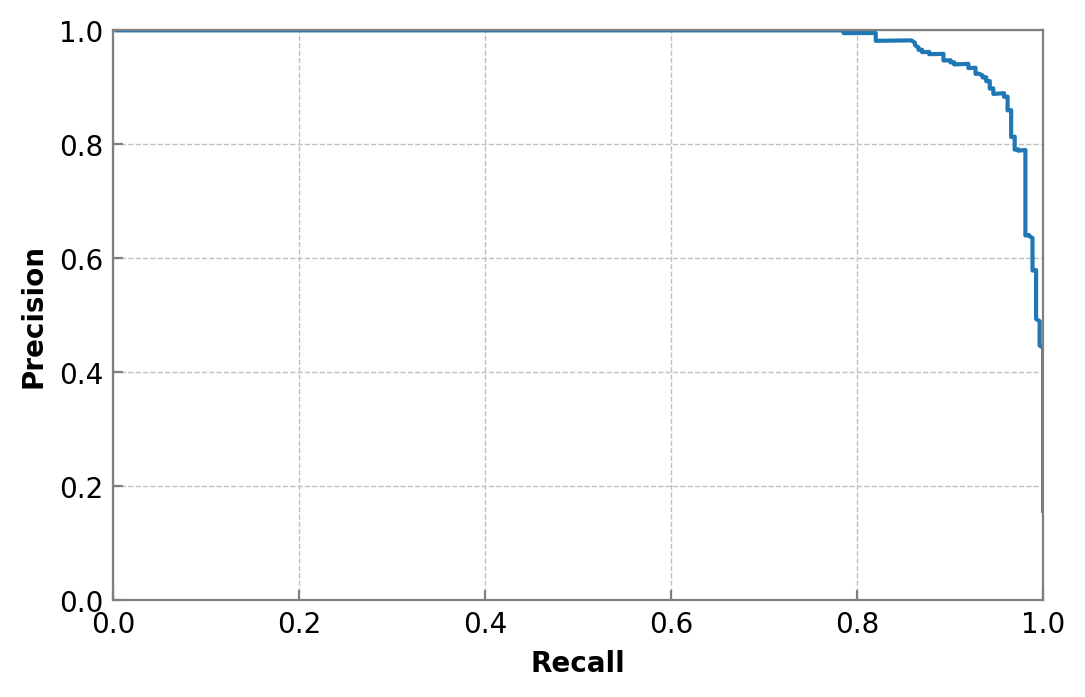

In [17]:
from matplotlib import pyplot as plt

ps, rs, ths = ([], [], [])
th = np.max(pred_es)
while th >= 0.0:
    p, r = pr_at_th(th)
    ps.append(p)
    rs.append(r)
    ths.append(th)
    th -= 0.0005
    
from sklearn import metrics

print(f'AUC: {metrics.auc(rs, ps)}, max R: {max(rs)}, max P: {max(ps)}')
    
i = len(rs) - 1
while rs[i] == 1.0:
    i -= 1
i += 1
print(f'100% recall at: {int(ps[i] * 100)}%, threshold: {ths[i]}')

fig, ax = plt.subplots(figsize=(6, 3.7), dpi=200)

ax.spines['top'].set_color('#808080')
ax.spines['right'].set_color('#808080')
ax.spines['left'].set_color('#808080')
ax.spines['bottom'].set_color('#808080')
ax.tick_params(direction='in', color='#808080')

plt.grid(color='#c0c0c0', linestyle='--', linewidth=0.5)

plt.ylabel('Precision', fontweight='bold')
plt.xlabel('Recall', fontweight='bold')

plt.xlim((0.0, 1.0))
plt.ylim((0.0, 1.0))

_ = plt.plot(rs, ps)

In [18]:
i = 0
while ps[i] > 0.749:
    i += 1
print(f'74.9% precision at: {int(rs[i] * 100)}%, threshold: {ths[i]}')

74.9% precision at: 98%, threshold: 0.1369900460243772
